In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn import MLP, GaussianFourierEmbedding
from probjax.nn.nets.flow_matching_model import RectifiedFlow


In [3]:
def generate_data(key):
    # Mixture of Gaussians
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey)
    eps = jax.random.normal(subkey, (2,))
    x = jnp.where(u < 0.5, eps[0]-3., eps[1]+3)
    return x[None]

2024-12-11 15:40:35.889652: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


[3.158]


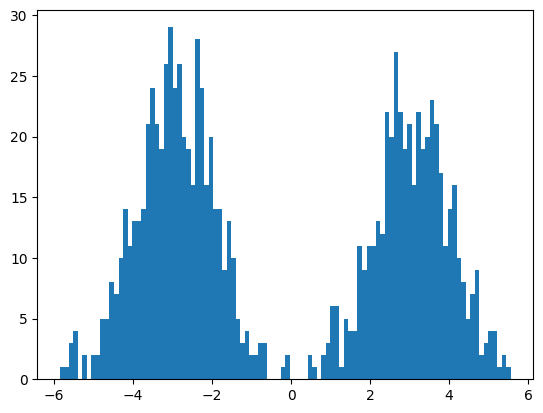

In [4]:
xs = jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 1000))
print(xs.std(0))
_ = plt.hist(xs.flatten(), bins=100)

In [5]:
d = 1
class BaseModel(nnx.Module, experimental_pytree=True):
    def __init__(self, d, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,8, rngs=rngs)
        #self.time_embedding = lambda t: jnp.repeat(t, 5, axis=-1)
        self.mlp = MLP([8+8,100,100,100,d], rngs=rngs)

    def __call__(self, t,x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        x = jnp.repeat(x, time_embed.shape[-1], axis=-1)
        inp = jnp.concatenate([time_embed, x], axis=-1)
        output = self.mlp(inp)
        return output

net = BaseModel(1, nnx.Rngs(0))
model = RectifiedFlow(net,std0=1., std1=3.5)
params = nnx.state(model, nnx.Param)

In [6]:

import optax

opt = optax.chain(optax.adaptive_grad_clip(10.), optax.ema(0.001), optax.adamw(1e-4))
opt_state = opt.init(params)
@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(model.loss)(params, rng,x)
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [7]:
key = jax.random.key(0)

In [8]:
losses = []
for i in range(600):
    l = 0.
    for j in range(10):
        key,key_data, key_loss = jax.random.split(key, 3)
        xs = jax.vmap(generate_data)(jax.random.split(key_data, 1000))
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    losses.append(l/10)

In [9]:
nnx.update(model, params)

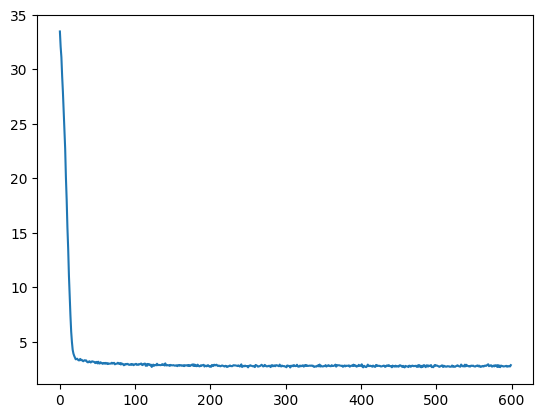

In [10]:
plt.plot(losses)

In [11]:
from probjax.utils.odeint import odeint


def sample(rng):
    eps = jax.random.normal(rng, (d,)) * model.std0.value + model.mu0.value
    ts = model.solve_schedule(50)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        v = model(t, x) # Why is this negative?
        return v.reshape(x.shape)

    return odeint(drift, eps,ts, method="euler")


In [12]:
keys = jax.random.split(key, (10_000,))
xs = jax.vmap(sample)(keys)

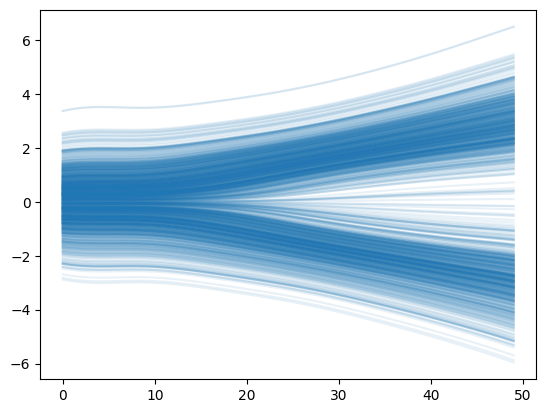

In [13]:
_ = plt.plot(xs[::10,:,0].T, color="C0", alpha=0.1)
#plt.ylim(-10,10)

(-7.0, 7.0)

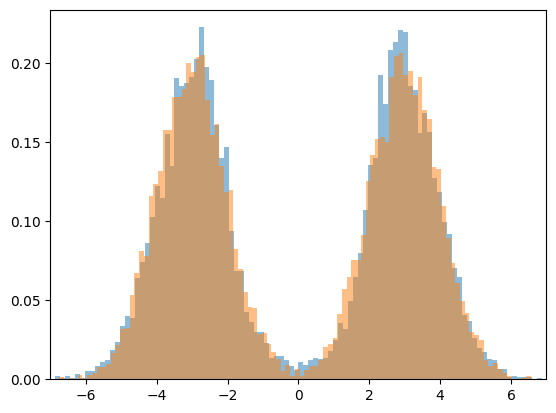

In [14]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-7,7), alpha=0.5)
_ = plt.hist(jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 10000)).flatten(), bins=100, density=True, alpha=0.5)

plt.xlim(-7,7)

In [27]:
from probjax.utils.sdeint import sdeint

# Stochastic sampling

def sample(rng):
    rng_init, rng_solve = jax.random.split(rng)
    eps = jax.random.normal(rng_init, (d,)) * model.std0.value + model.mu0.value
    ts = model.solve_schedule(50) 

    # One cannot add too much noise, as network was trained without!
    def diffusion(t, x):
        g = jnp.sqrt((1-t)*t) * 0.3
        return g* jnp.ones_like(x)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        v = model(t, x) 
        s = model.score(t, x, max_t=0.99)
        g = diffusion(t, x)
        return v + 0.5*g**2 * s

    return sdeint(rng_solve, drift, diffusion, eps,ts, method="euler_maruyama")


In [28]:
keys = jax.random.split(key, (10_000,))
xs = jax.vmap(sample)(keys)

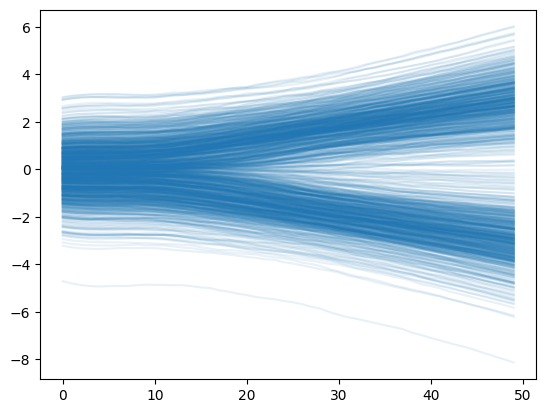

In [29]:
_ = plt.plot(xs[::10,:,0].T, color="C0", alpha=0.1)
#plt.ylim(-10,10)

(-7.0, 7.0)

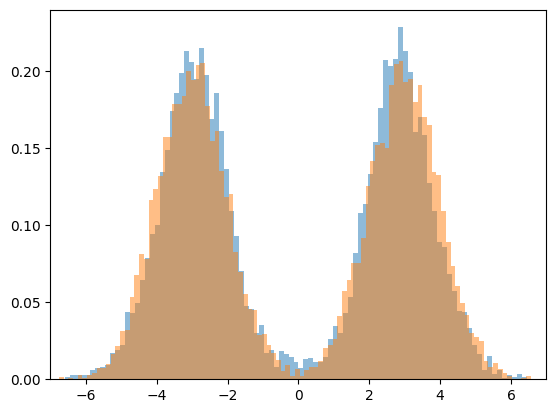

In [31]:
_ = plt.hist(xs[:,-1].flatten(), bins=100, density=True, range=(-7,7), alpha=0.5)
_ = plt.hist(jax.vmap(generate_data)(jax.random.split(jax.random.PRNGKey(0), 10000)).flatten(), bins=100, density=True, alpha=0.5)

plt.xlim(-7,7)